# [영화 평가 데이터](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data)
- 이 파일에는 Full MovieLens 데이터셋에 등록된 45,000편의 영화에 대한 메타데이터가 포함되어 있습니다.
- 이 데이터셋은 2017년 7월 이전에 개봉한 영화로 구성되어 있습니다. 데이터 포인트에는 출연진, 제작진, 줄거리 키워드, 예산, 수익, 포스터, 개봉일, 언어, 제작사, 국가, TMDB 투표 수 및 투표 평균 등이 포함됩니다.
- 이 데이터세트에는 45,000편의 영화에 대해 27만 명의 사용자가 작성한 2,600만 건의 평점이 포함된 파일도 포함되어 있습니다.
- 평점은 1점부터 5점까지의 점수로 매겨지며, GroupLens 공식 웹사이트에서 수집되었습니다.

## 데이터(파일) 설명

- movies_metadata.csv
  - 주요 영화 메타데이터 파일입니다.
  - Full MovieLens 데이터세트에 포함된 45,000편의 영화에 대한 정보가 포함되어 있습니다.
  - 포스터, 배경, 예산, 수익, 개봉일, 언어, 제작 국가 및 제작사 등의 정보가 포함됩니다.
  - 문자열화된 JSON 객체 형태로 제공됩니다.
- links_small.csv
  - 전체 데이터 세트의 9,000개 영화 중 작은 하위 세트의 TMDB 및 IMDB ID를 포함합니다.

# 데이터

In [ ]:
import pandas as pd
from ast import literal_eval

## 데이터 로드

> movies_metadata는 영화에 대한 메타데이터(제목, 장르 등)이다.

In [ ]:
movies_metadata = pd.read_csv(DATA_PATH+'movies_metadata.csv')

movies_metadata.shape

/tmp/ipython-input-5-2843536420.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv(DATA_PATH+'movies_metadata.csv')


(45466, 24)

In [ ]:
movies_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

### 데이터 줄이자

> links_small.csv를 이용하여 movies_metadata의 데이터 수를 줄이자   
> 너무 데이터가 많으면, 전처리 및 추천할 때, 시간이 오래 걸리거나 메모리가 부족한 경우가 발생할 수 있다.

In [ ]:
links_small = pd.read_csv(DATA_PATH+'links_small.csv')

links_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9125 non-null   int64  
 1   imdbId   9125 non-null   int64  
 2   tmdbId   9112 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 214.0 KB


In [ ]:
# 결측치 제거 및 데이터 형변환
links_small = links_small[links_small['tmdbId'].notnull()]['tmdbId'].astype('int')
links_small.shape

(9112,)

In [ ]:
# links_small에 포함된 id만 사용
movies_metadata_small = movies_metadata[movies_metadata['id'].isin(links_small.astype('str'))]
movies_metadata_small.shape

(9099, 24)

### 필요한 컬럼만 정의하자

> 추천에 필요한 컬럼만 사용하기   
> title(영화 제목), genres(영화 장르), popularity(영화 인기도), release_date(영화 개볼일)

In [ ]:
columns = ['title', 'genres', 'popularity', 'release_date']

movies = movies_metadata_small[columns]
movies.head()

,title,genres,popularity,release_date
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",21.946943,1995-10-30
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",17.015539,1995-12-15
2,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",11.7129,1995-12-22
3,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",3.859495,1995-12-22
4,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",8.387519,1995-02-10


## 데이터 전처리

### 장르(genres) 전처리

> genres 추출    
> 추천을 할때 genres(장르)가 비슷한 영화들을 추천하자

In [ ]:
movies[['genres']].loc[0].values[0]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

```python
# genres(장르)에서 [] 데이터는 제외하고
movies['genres'].fillna('[]')\
  # 문자열을 dictionary 데이터로 변환
  .apply(literal_eval)\
  # 장르 데이터를 추출해서 리스트에 넣기
  .apply(lambda x: sorted([i['name'] for i in x]) if isinstance(x, list) else [])\
  # 리스트의 장르 데이터를 하나의 문자열로 변환
  .apply(lambda x: " ".join(x) if len(x) > 0 else None)

```

In [ ]:
movies['str_genres'] = movies['genres'].fillna('[]')\
                    .apply(literal_eval)\
                    .apply(lambda x: sorted([i['name'] for i in x]) if isinstance(x, list) else [])\
                    .apply(lambda x: " ".join(x) if len(x) > 0 else None)

movies[['str_genres', 'genres']].head()

/tmp/ipython-input-12-1520763127.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['str_genres'] = movies['genres'].fillna('[]')\


,str_genres,genres
0,Animation Comedy Family,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,Adventure Family Fantasy,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,Comedy Romance,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ..."
3,Comedy Drama Romance,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
4,Comedy,"[{'id': 35, 'name': 'Comedy'}]"


In [ ]:
movies[['str_genres', 'genres']].tail()

,str_genres,genres
40224,Action Adventure Drama Horror Science Fiction,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
40503,Documentary Music,"[{'id': 99, 'name': 'Documentary'}, {'id': 104..."
44821,Action Adventure Animation Family Fantasy,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
44826,Adventure Animation Family Fantasy Science Fic...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
45265,Comedy Drama,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."


### 개봉일(release_date) 전처리

> release_date의 문자열 데이터를 날짜 데이터로 형변환    
> 날짜 데이터로 변환하게 되면, 년/월/일 등의 데이터를 추출하기 쉬워진다.

In [ ]:
movies[['title', 'release_date']].head()

,title,release_date
0,Toy Story,1995-10-30
1,Jumanji,1995-12-15
2,Grumpier Old Men,1995-12-22
3,Waiting to Exhale,1995-12-22
4,Father of the Bride Part II,1995-02-10


In [ ]:
# release_date의 데이터 타입이 문자열(object)임을 확인할 수 있다.
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9099 entries, 0 to 45265
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         9099 non-null   object
 1   genres        9099 non-null   object
 2   popularity    9099 non-null   object
 3   release_date  9099 non-null   object
 4   str_genres    9064 non-null   object
dtypes: object(5)
memory usage: 684.6+ KB


> errors='coerce'를 입력하면, 변환할 수 있는 데이터는 수치형으로 변환되고 변환할 수 없는 데이터는 NaN으로 처리됩니다.   
> NaN은 Not a Number의 약자입니다.

In [ ]:
# 문자열(object)를 날짜(datetime64)로 데이터 형변환
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

# 결과 확인
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9099 entries, 0 to 45265
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         9099 non-null   object        
 1   genres        9099 non-null   object        
 2   popularity    9099 non-null   object        
 3   release_date  9099 non-null   datetime64[ns]
 4   str_genres    9064 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 684.6+ KB


/tmp/ipython-input-16-1583773313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')


> release_date를 이용하여 year(년도)를 추출하자   
> 추천을 할때 가능하면 최신 년도를 추천하자

In [ ]:
movies['year'] = movies['release_date'].dt.year

movies[['release_date', 'year']].head()

/tmp/ipython-input-17-3364271264.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['year'] = movies['release_date'].dt.year


,release_date,year
0,1995-10-30,1995
1,1995-12-15,1995
2,1995-12-22,1995
3,1995-12-22,1995
4,1995-02-10,1995


## 데이터 결측치 제거

> 각 컬럼별 결측치 비율 확인

```python
# movies.isnull().sum() -> 컬럼별 결측치의 합
# movies.shape[0] -> 전체 데이터의 수
# (movies.isnull().sum() / movies.shape[0])
# -> 각 컬럼별 결측치의 비율
(movies.isnull().sum() / movies.shape[0])\
  # 소수점 4자리까지만 표현
  .round(4)\
  # 가장 높은 비율(결측치) 순으로 정렬
  .sort_values(ascending=False)

```

In [ ]:
print(f"movies.shape: {movies.shape}")
(movies.isnull().sum() / movies.shape[0])\
  .round(4)\
  .sort_values(ascending=False)

movies.shape: (9099, 6)


,0
str_genres,0.0038
title,0.0000
genres,0.0000
popularity,0.0000
release_date,0.0000
year,0.0000


> 결측치 데이터 제거하기

In [ ]:
# 결측치 데이터 제거
movies = movies.dropna()
# 인덱스 재정의
movies = movies.reset_index(drop=True)

# 확인
print(f"movies.shape: {movies.shape}")
(movies.isnull().sum() / movies.shape[0])\
  .round(4)\
  .sort_values(ascending=False)

movies.shape: (9064, 6)


,0
title,0.0
genres,0.0
popularity,0.0
release_date,0.0
str_genres,0.0
year,0.0


# BoW 기반 Contents Based Filtering
- BoW 기반 Contents Based Filtering이란?
  -  BoW(Bag of Word) 기반 문서-단어 행렬을 활용하여 문장의 유사도 추천   
  - 좀더 구체적으로 설명하면, 단어들의 출현 빈도를 이용하여 단어들을 벡터화한 후 유사도 추천을 한다.

즉 해당 기술을 이용해서 추천을 한다는 것은 A 영화를 좋아하는 사람에게 A와 비슷한 장르의 영화들을 추천하면, 좋아할 확률이 높아진다는 뜻이 된다.

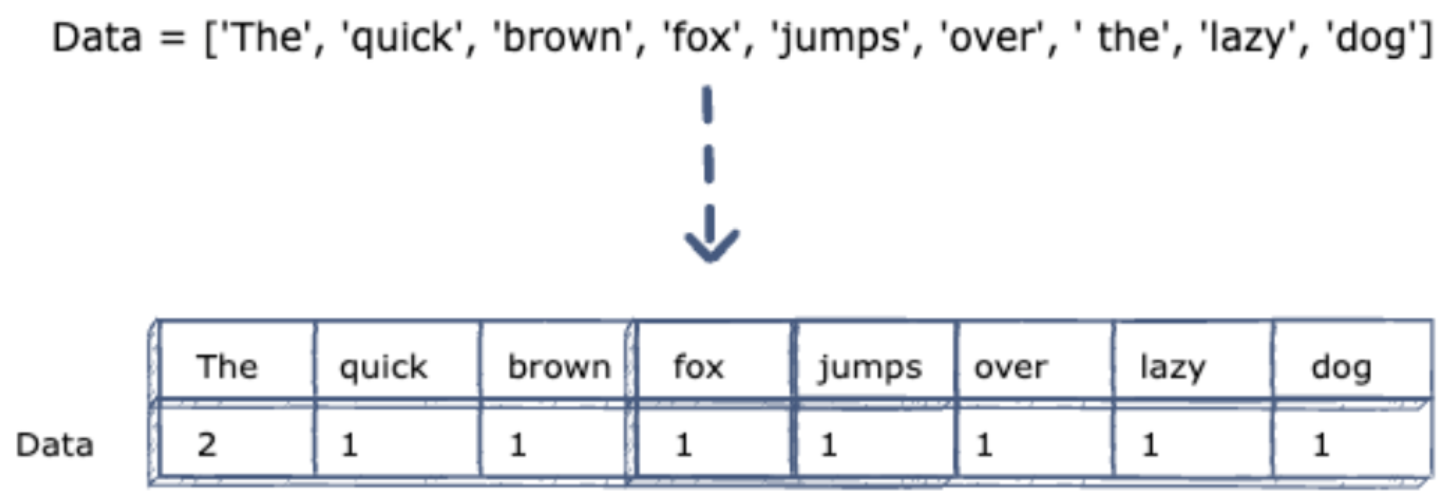

## 장르 데이터를 Bow 기반 벡터 데이터로 변환

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

> CountVectorizer는 문장에 포함된 단어 수를 이용하여 벡터로 변환하는 객체이다.

In [ ]:
bow_vectorizer = CountVectorizer()

> 장르 데이터를 2차원의 메트릭스 데이터로 변환

In [ ]:
# 장르 데이터를 2차원의 메트릭스 데이터로 변환
genre_mat = bow_vectorizer.fit_transform(movies['str_genres'])

> 전체 장르 데이터에서 각 장르별 언급된 횟수 확인

In [ ]:
bow_vectorizer.vocabulary_

{'animation': 2,
 'comedy': 3,
 'family': 7,
 'adventure': 1,
 'fantasy': 8,
 'romance': 16,
 'drama': 6,
 'action': 0,
 'crime': 4,
 'thriller': 18,
 'horror': 12,
 'history': 11,
 'science': 17,
 'fiction': 9,
 'mystery': 15,
 'war': 20,
 'foreign': 10,
 'music': 14,
 'documentary': 5,
 'western': 21,
 'tv': 19,
 'movie': 13}

> 변환된 메트릭스(장르) 확인

In [ ]:
# (전체 데이터 수, 전체 장르 수)
genre_mat.shape

(9064, 22)

In [ ]:
genre_mat.toarray()

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

### 해석하기

In [ ]:
# 이 영화의 장르 데이터를
movies[['title', 'str_genres']].iloc[0]

,0
title,Toy Story
str_genres,Animation Comedy Family


In [ ]:
movies[['str_genres']].loc[0].values[0]

'Animation Comedy Family'

In [ ]:
print(f"Animation >> {bow_vectorizer.vocabulary_['animation']}")
print(f"Comedy >> {bow_vectorizer.vocabulary_['comedy']}")
print(f"Family >> {bow_vectorizer.vocabulary_['family']}")

Animation >> 2
Comedy >> 3
Family >> 7


In [ ]:
# 하나의 백터 데이터로 변환됨
# 해당 숫자의 정보는 장르가 언급된 숫자(BoW(Bag of Word))를 기반으로 변환됨
genre_mat.toarray()[0]

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## 코싸인 유사도 측정
- 1에 가까울 수록 유사함(90도보다 작은 경우)
- 0인 경우에는 관련없음(90도인 경우)
- -1인 경우에는 서로 반대 성향(90도보다 큰 경우)

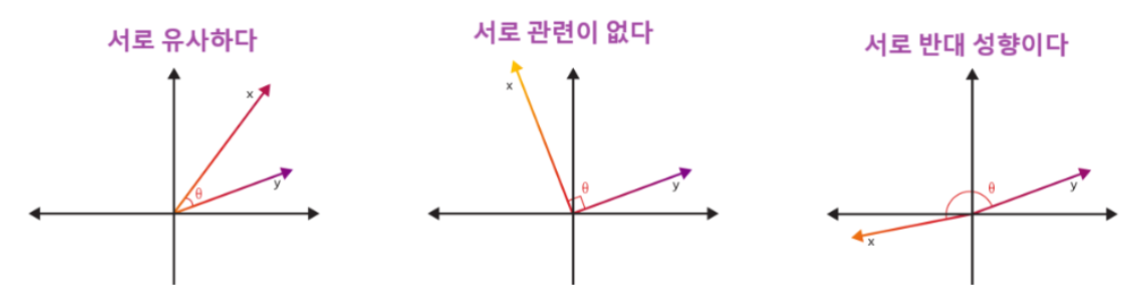

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

### 1.영화별 유사도 연산

In [ ]:
similarity_of_genre = cosine_similarity(genre_mat, genre_mat)

# shape -> (전체 데이터 수, 전체 데이터 수)
similarity_of_genre.shape

(9064, 9064)

> 메트릭스 형테의 유사도 데이터이다.

In [ ]:
similarity_of_genre

array([[1.        , 0.33333333, 0.40824829, ..., 0.51639778, 0.47140452,
        0.40824829],
       [0.33333333, 1.        , 0.        , ..., 0.77459667, 0.70710678,
        0.        ],
       [0.40824829, 0.        , 1.        , ..., 0.        , 0.        ,
        0.5       ],
       ...,
       [0.51639778, 0.77459667, 0.        , ..., 1.        , 0.73029674,
        0.        ],
       [0.47140452, 0.70710678, 0.        , ..., 0.73029674, 1.        ,
        0.        ],
       [0.40824829, 0.        , 0.5       , ..., 0.        , 0.        ,
        1.        ]])

#### 확인하기

> 0번째 영화와 다른 영화간의 유사도 값   
> 0번째 영화는 자기 자신(0번째 영화)의 유사도 값임(=1)   
> 1번째 영화는 0번째 영화와 유사도 값이 0.333..임  

In [ ]:
movie0_similarity = similarity_of_genre[0]
movie0_similarity

array([1.        , 0.33333333, 0.40824829, ..., 0.51639778, 0.47140452,
       0.40824829])

> 0번째 영화와 1번째 영화의 장르 확인

In [ ]:
movies[['title', 'str_genres']].iloc[0:2, :]

,title,str_genres
0,Toy Story,Animation Comedy Family
1,Jumanji,Adventure Family Fantasy


### 2.유사도가 높은 영화의 index값으로 정렬

> 유사도가 낮은 영화의 index값으로 변환

In [ ]:
sorted_similarity_of_genre = similarity_of_genre.argsort()

sorted_similarity_of_genre

array([[3598, 3615, 3559, ..., 2718, 7064,    0],
       [4769, 7810, 7811, ..., 8327, 5010,    1],
       [3378, 6845, 6816, ...,    6,   49,   60],
       ...,
       [4085, 4068, 4066, ..., 9061, 3358, 7904],
       [4354, 4373, 4374, ..., 3020, 4340, 4238],
       [1546, 1536, 1537, ..., 6537, 3404, 3394]])

> 유사도가 높은 영화의 indexr값으로 재정렬

In [ ]:
sorted_similarity_of_genre = sorted_similarity_of_genre[:, ::-1]

sorted_similarity_of_genre

array([[   0, 7064, 2718, ..., 3559, 3615, 3598],
       [   1, 5010, 8327, ..., 7811, 7810, 4769],
       [  60,   49,    6, ..., 6816, 6845, 3378],
       ...,
       [7904, 3358, 9061, ..., 4066, 4068, 4085],
       [4238, 4340, 3020, ..., 4374, 4373, 4354],
       [3394, 3404, 6537, ..., 1537, 1536, 1546]])

#### 검증하기

> 0번째 영화와 가장 높은 유사도를 갖은 영화들은 왼쪽으로..    
> 0번째 영화와 가장 낮은 유사도를 갖은 영화들은 오른쪽으로..

In [ ]:
# 0번째 영화와 가장 유사한 영화들의 index 리스트
movie0_index_of_similarity = sorted_similarity_of_genre[0]

# 첫번째 가장 유사한 영화 index는 0인데, 이것은 같은 영화임으로 제외하고
# 두번째 index값이 가장 0번째 영화와 유사하다고 해석할 수 있음
movie0_index_of_similarity

array([   0, 7064, 2718, ..., 3559, 3615, 3598])

> 따라서 가장 유사한 두번째 index값의 영화 확인

In [ ]:
movie_index_of_max = movie0_index_of_similarity[1]
movie_index_of_max

np.int64(7064)

> 0번째 영화와 두번째 index의 영화에 대한 유사도 값 확인

In [ ]:
# movie0_similarity는 0번째 영화에 대한 다른 영화들의 유사도 값들이 저장되어 있음.
movie0_similarity[movie_index_of_max]

np.float64(1.0000000000000002)

> 장르 데이터 확인

In [ ]:
movies[['title', 'str_genres']].iloc[[0, movie_index_of_max], :]

,title,str_genres
0,Toy Story,Animation Comedy Family
7064,A Matter of Loaf and Death,Animation Comedy Family


> 마지막 index 영화는 0번째 영화와 유사도가 가장 작다.

In [ ]:
movie_index_of_min = movie0_index_of_similarity[-1]
movie_index_of_min

np.int64(3598)

> 0번째 영화와 마지막 index 영화에 대한 유사도 값 확인

In [ ]:
# movie0_similarity는 0번째 영화에 대한 다른 영화들의 유사도 값들이 저장되어 있음.
movie0_similarity[movie_index_of_min]

np.float64(0.0)

> 장르 데이터 확인

In [ ]:
movies[['title', 'str_genres']].iloc[[0, movie_index_of_min], :]

,title,str_genres
0,Toy Story,Animation Comedy Family
3598,An Innocent Man,Action Crime Drama Thriller


## 컨텐츠 기반 추천 예제

In [ ]:
# title_name -> 컨텐츠 기반 추천을 위한 기준 영화 제목
# top_k -> 몇 개의 영화를 추천할지...
def recommendation(title_name, top_k=5):
  # 기준 영화 추출
  movie_of_title = movies[movies['title'] == title_name]
  print(f"{title_name}의 장르: {movie_of_title['str_genres'].values[0]}")

  # 기준 영화 인덱스
  movie_index_of_title = movie_of_title.index.values[0]

  # 기준 영화를 기준으로 가장 유사도가 높은 영화들의 인덱스 추출
  similar_indexes = sorted_similarity_of_genre[movie_index_of_title, :(top_k*2)]
  # 메트릭스(2차원의 데이터)를 벡터(1차원의 데이터)로 변환
  similar_indexes = similar_indexes.reshape(-1)
  # 기준 영화 인덱스는 제외
  similar_indexes = similar_indexes[similar_indexes != movie_index_of_title]

  # 유사도 기반으로 추출된 영화 추천
  return movies.iloc[similar_indexes].sort_values(by=['year'], ascending=False)[:top_k]

In [ ]:
recommendation_movies = recommendation('An Innocent Man')

recommendation_movies[['title', 'str_genres', 'year']]

An Innocent Man의 장르: Action Crime Drama Thriller


,title,str_genres,year
7922,Contraband,Action Crime Drama Thriller,2012
7907,The Dark Knight Rises,Action Crime Drama Thriller,2012
5916,Infernal Affairs II,Action Crime Drama Thriller,2003
3786,Heist,Action Crime Drama Thriller,2001
4795,Time and Tide,Action Crime Drama Thriller,2000


In [ ]:
recommendation_movies = recommendation('Toy Story')

recommendation_movies[['title', 'str_genres', 'year']]

Toy Story의 장르: Animation Comedy Family


,title,str_genres,year
8372,Cloudy with a Chance of Meatballs 2,Animation Comedy Family,2013
7511,Toy Story 3,Animation Comedy Family,2010
7064,A Matter of Loaf and Death,Animation Comedy Family,2008
7149,Kung Fu Panda: Secrets of the Furious Five,Animation Comedy Family,2008
3783,"Monsters, Inc.",Animation Comedy Family,2001
